In [2]:
import numpy as np
import pandas as pd

np.random.seed(23)

mu_vec1 = np.array([0, 0, 0])
cov_mat = np.eye(3)
class1 = np.random.multivariate_normal(mu_vec1, cov_mat, 20)

df1 = pd.DataFrame(class1, columns=['feature1', 'feature2', 'feature3'])
df1['target'] = 1

mu_vec2 = np.array([1, 1, 1])
class2 = np.random.multivariate_normal(mu_vec2, cov_mat, 20)

df2 = pd.DataFrame(class2, columns=['feature1', 'feature2', 'feature3'])
df2['target'] = 0

df = pd.concat([df1, df2], ignore_index=True)
df = df.sample(frac=1, random_state=23).reset_index(drop=True)


In [3]:
df.head()

,feature1,feature2,feature3,target
0,-0.331617,-1.632386,0.619114,1
1,1.010229,1.437830,2.327788,0
2,0.241106,-0.952510,-0.136267,1
3,1.676860,4.187503,-0.080565,0
4,2.823378,-0.332863,2.637391,0


In [5]:
import plotly.express as px
fig=px.scatter_3d(df,x=df['feature1'],y=df['feature2'],z=df['feature3'],color=df['target'].astype('str'))
fig.update_traces(marker=dict(size=12,line=dict(width=2,
                                                color='DarkSlateGrey')),
                  selector=dict(mode='markers'))
fig.show()

In [6]:
from sklearn.preprocessing import StandardScaler
sc=StandardScaler()

In [7]:
df.iloc[:,0:3]=sc.fit_transform(df.iloc[:,0:3])

In [9]:
cov_mat=np.cov([df.iloc[:,0],df.iloc[:,1],df.iloc[:,2]])
cov_mat

array([[1.02564103, 0.20478114, 0.080118  ],
       [0.20478114, 1.02564103, 0.19838882],
       [0.080118  , 0.19838882, 1.02564103]])

In [10]:
eigen_values,eigen_vectors=np.linalg.eig(cov_mat)

In [11]:
eigen_values

array([1.3536065 , 0.94557084, 0.77774573])

In [12]:
eigen_vectors

array([[-0.53875915, -0.69363291,  0.47813384],
       [-0.65608325, -0.01057596, -0.75461442],
       [-0.52848211,  0.72025103,  0.44938304]])

Populating the interactive namespace from numpy and matplotlib


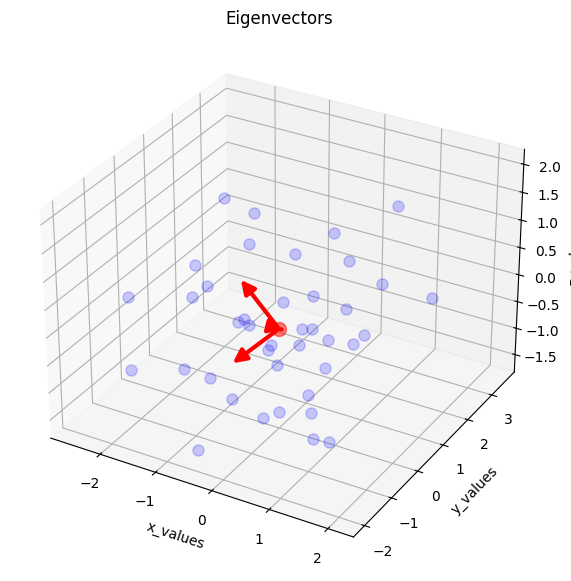

In [14]:
%pylab inline

from matplotlib import pyplot as plt
from mpl_toolkits.mplot3d import Axes3D, proj3d
from matplotlib.patches import FancyArrowPatch
import numpy as np


class Arrow3D(FancyArrowPatch):
    def __init__(self, xs, ys, zs, *args, **kwargs):
        super().__init__((0, 0), (0, 0), *args, **kwargs)
        self._verts3d = xs, ys, zs

    def draw(self, renderer):
        xs3d, ys3d, zs3d = self._verts3d
        xs, ys, zs = proj3d.proj_transform(xs3d, ys3d, zs3d, self.axes.M)
        self.set_positions((xs[0], ys[0]), (xs[1], ys[1]))
        super().draw(renderer)

    # 🔥 REQUIRED FIX
    def do_3d_projection(self, renderer=None):
        xs3d, ys3d, zs3d = self._verts3d
        _, _, zs = proj3d.proj_transform(xs3d, ys3d, zs3d, self.axes.M)
        return np.min(zs)


fig = plt.figure(figsize=(7, 7))
ax = fig.add_subplot(111, projection='3d')

# Data points
ax.plot(
    df['feature1'],
    df['feature2'],
    df['feature3'],
    'o',
    markersize=8,
    color='blue',
    alpha=0.2
)

# Mean point
mean_x = df['feature1'].mean()
mean_y = df['feature2'].mean()
mean_z = df['feature3'].mean()

ax.plot([mean_x], [mean_y], [mean_z],
        'o', markersize=10, color='red', alpha=0.5)

# Eigenvectors
for v in eigen_vectors.T:
    a = Arrow3D(
        [mean_x, mean_x + v[0]],
        [mean_y, mean_y + v[1]],
        [mean_z, mean_z + v[2]],
        mutation_scale=20,
        lw=3,
        arrowstyle="-|>",
        color="r"
    )
    ax.add_artist(a)

ax.set_xlabel('x_values')
ax.set_ylabel('y_values')
ax.set_zlabel('z_values')
plt.title('Eigenvectors')

plt.show()


In [15]:
pc=eigen_vectors[0:2]
pc

array([[-0.53875915, -0.69363291,  0.47813384],
       [-0.65608325, -0.01057596, -0.75461442]])

In [16]:
transform_df=np.dot(df.iloc[:,0:3],pc.T)

new_df=pd.DataFrame(transform_df,columns=['PC1','PC2'])
new_df['target']=df['target']
new_df.head()

,PC1,PC2,target
0,1.726114,0.492511,1
1,-0.220797,-1.441911,0
2,0.688605,0.658084,1
3,-3.367715,-0.254627,0
4,0.227326,-2.669841,0


In [17]:
new_df['target'] = new_df['target'].astype('str')
fig = px.scatter(x=new_df['PC1'],
                 y=new_df['PC2'],
                 color=new_df['target'],
                 color_discrete_sequence=px.colors.qualitative.G10
                )

fig.update_traces(marker=dict(size=12,
                              line=dict(width=2,
                                        color='DarkSlateGrey')),
                  selector=dict(mode='markers'))
fig.show()

see pca lec 49